In [16]:
import pandas as pd
import matplotlib.pyplot as plt

import seaborn as sns

In [17]:
df = pd.read_csv("Wine_dataset.csv", usecols=[0,1,2])

In [18]:
df.head()


,class,Alcohol,Malic acid
0,1,14.23,1.71
1,1,13.20,1.78
2,1,13.16,2.36
3,1,14.37,1.95
4,1,13.24,2.59


<Axes: xlabel='Alcohol', ylabel='Density'>

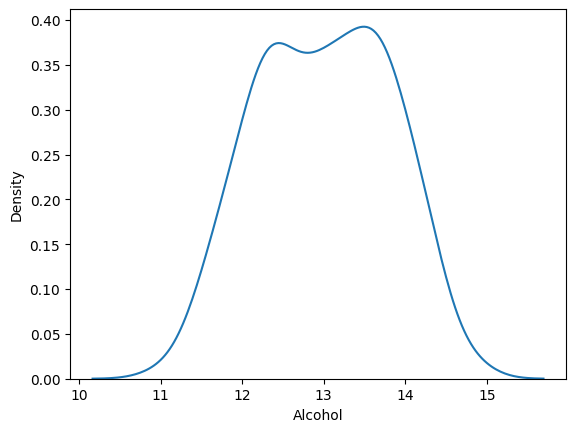

In [19]:
sns.kdeplot(x=df['Alcohol'])

<Axes: xlabel='Malic acid', ylabel='Density'>

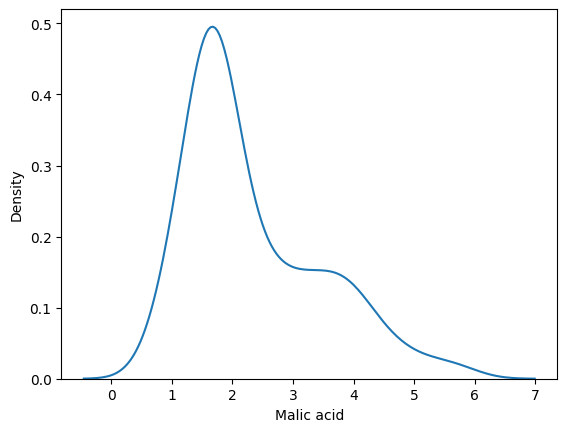

In [20]:
sns.kdeplot(x=df['Malic acid'])

<Axes: xlabel='Alcohol', ylabel='Malic acid'>

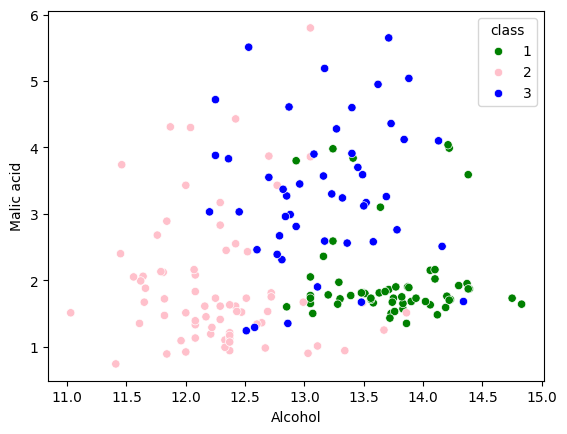

In [21]:
color_dict = {1:'Green', 2:'Pink', 3: 'Blue'}
sns.scatterplot(x=df['Alcohol'],y= df['Malic acid'], hue= df['class'], palette=color_dict)

In [24]:
from sklearn.model_selection import train_test_split
X_train, X_test, Y_train, Y_test = train_test_split(
                        df.drop('class', axis=1), 
                        df['class'], test_size=0.2,random_state=0)


X_train.shape

In [25]:
X_train.shape, X_test.shape

((142, 2), (36, 2))

In [29]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [32]:
# Y_train_scaled = scaler.fit_transform(Y_train)
# Y_test_scaled = scaler.transform(Y_test)

In [36]:
X_train_scaled = pd.DataFrame(X_train_scaled, columns= X_train.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns)

In [37]:
X_test_scaled.head()

,Alcohol,Malic acid
0,0.728495,0.189409
1,0.473118,0.393075
2,0.360215,0.079430
3,0.680108,0.201629
4,0.543011,1.030550


In [35]:
X_train_scaled.head()

,Alcohol,Malic acid
0,0.715054,0.513238
1,0.446237,0.160896
2,0.158602,0.254582
3,0.637097,0.645621
4,0.663978,0.217923


In [38]:
import numpy as np

In [40]:
np.round(X_train.describe(),1)

,Alcohol,Malic acid
count,142.0,142.0
mean,13.0,2.4
std,0.8,1.1
min,11.0,0.7
25%,12.3,1.6
50%,13.0,1.9
75%,13.6,3.2
max,14.8,5.6


In [41]:
np.round(X_train_scaled.describe(),1)

,Alcohol,Malic acid
count,142.0,142.0
mean,0.5,0.3
std,0.2,0.2
min,0.0,0.0
25%,0.4,0.2
50%,0.5,0.2
75%,0.7,0.5
max,1.0,1.0


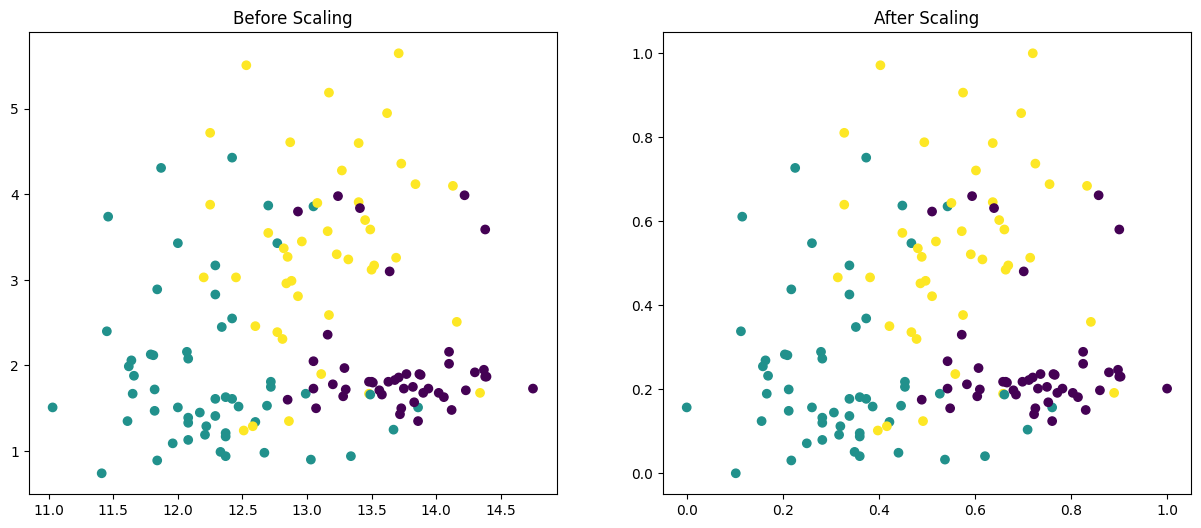

In [43]:
fig, (ax1,ax2) = plt.subplots(ncols=2, figsize =(15,6))
ax1.scatter(X_train['Alcohol'], X_train['Malic acid'], c =Y_train)
ax1.set_title('Before Scaling')

ax2.scatter(X_train_scaled['Alcohol'], X_train_scaled['Malic acid'], c=Y_train)
ax2.set_title('After Scaling')
plt.show()

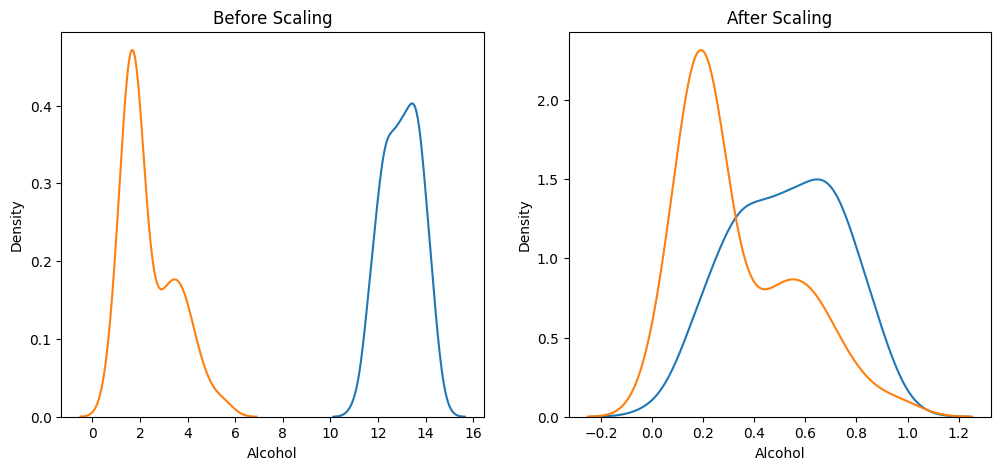

In [52]:
fig, (ax1,ax2) = plt.subplots(ncols=2, figsize = (12,5))
ax1.set_title("Before Scaling")
sns.kdeplot(X_train['Alcohol'], ax=ax1)
sns.kdeplot(X_train['Malic acid'], ax = ax1)

# plt.show()

ax2.set_title("After Scaling")
sns.kdeplot(x=X_train_scaled['Alcohol'], ax=ax2)
sns.kdeplot(x=X_train_scaled['Malic acid'], ax = ax2)
ax2.set_title("After Scaling")
plt.show()

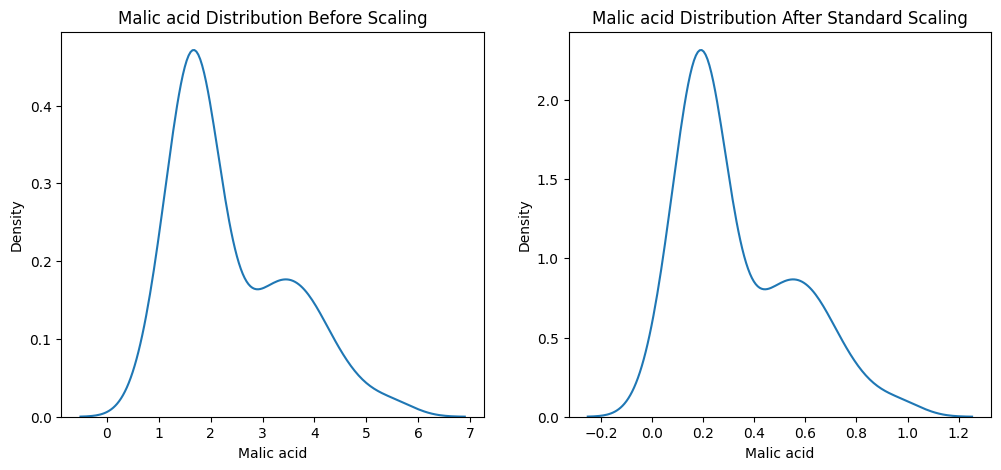

In [53]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12, 5))

# before scaling
ax1.set_title('Malic acid Distribution Before Scaling')
sns.kdeplot(X_train['Malic acid'], ax=ax1)

# after scaling
ax2.set_title('Malic acid Distribution After Standard Scaling')
sns.kdeplot(x= X_train_scaled['Malic acid'], ax=ax2)
plt.show()